
# 03 — Lensing convergence map vs theory

Generate a convergence map from a toy theoretical $C_\ell$, then measure its spectrum and compare back to the input theory.


In [1]:

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")


'cpu'

In [2]:

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

from fwd_model_tools.power import angular_cl_spherical


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
ERROR:2025-11-25 02:35:41,705:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cud

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [3]:

# Toy convergence theory: simple power-law C_ell
ells = jnp.arange(1, 256)
cl_kappa = 1.0 / (ells * (ells + 1))

lmax = int(ells[-1])
full_cl = np.zeros(lmax + 1)
full_cl[1:] = np.asarray(cl_kappa)


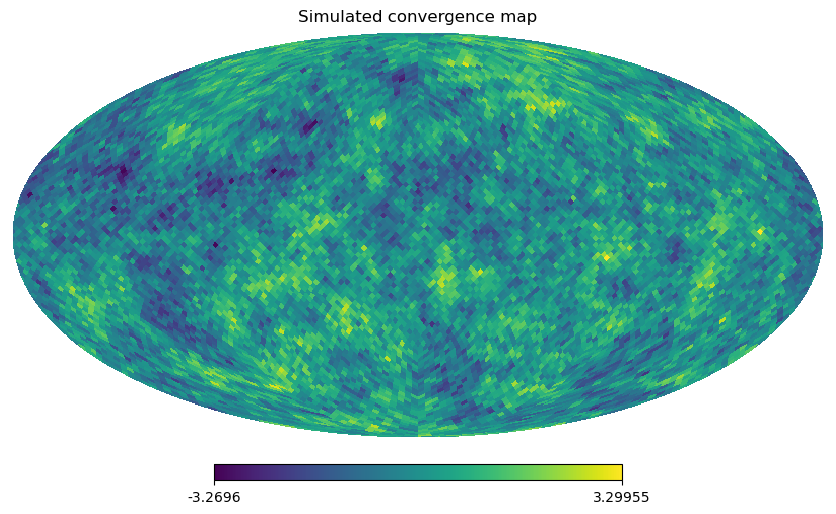

In [4]:

# Draw a HEALPix convergence map from the theory spectrum
nside = 32
kappa_map = hp.synfast(full_cl, nside=nside, lmax=lmax, pixwin=False, verbose=False)

hp.mollview(kappa_map, title="Simulated convergence map")
plt.show()


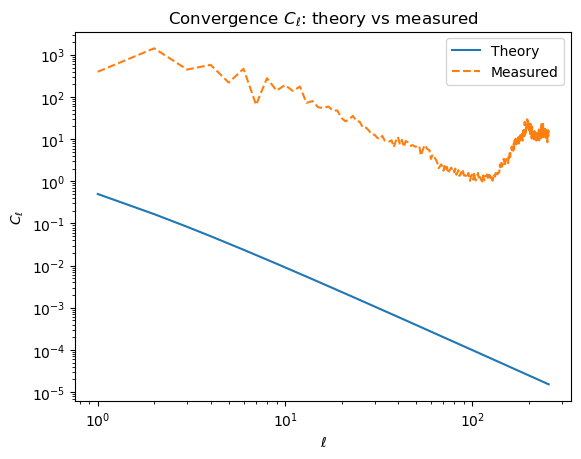

In [5]:

# Measure Cl from the simulated map and compare to theory
ell_meas, cl_meas = angular_cl_spherical(kappa_map, lmax=lmax)

plt.loglog(np.asarray(ells), np.asarray(cl_kappa), label="Theory")
plt.loglog(np.asarray(ell_meas[1:]), np.asarray(cl_meas[1:]), label="Measured", ls="--")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.title("Convergence $C_\ell$: theory vs measured")
plt.show()



**Notes**
- The map is a Gaussian realization of the toy $C_\ell$; differences come from sample variance.
- Swap in a cosmology-based $C_\ell$ to compare against realistic theory curves.
